## Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os

years = [2019, 2020, 2021, 2022, 2023, 2024]

modes = {}
graphs = {}

base_modes = "../../data/03_modes"

# List all year_month folders
year = "2019"

for speed in ["fast", "medium", "slow"]:
    file_path = f"../../data/04_graphs/{year}/{speed}_graph.gpickle"
    with open(file_path, "rb") as f:
        graphs[f"graph_{speed}_{year}"] = pickle.load(f)
                
        modes[f"{speed}_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/{speed}_emd.parquet")

## Funções

In [2]:
import community as community_louvain

def calculate_hybrid_risk_metric(G, weights=None):
    """
    Calculate the hybrid risk metric R_i for each node in PMFG graph G.
    
    Parameters:
        G (networkx.Graph): PMFG graph with weighted edges (correlations)
        weights (dict): Optional weights for the metrics:
            {
                'degree': float,
                'clustering': float,
                'betweenness': float,
                'edge_weight': float,
                'community': float,
                'kcore': float
            }
            Defaults to equal weights if None.
    
    Returns:
        dict: {node: risk_score (0-1, lower = less risk)}
    """
    # Default equal weights if not provided
    if weights is None:
        weights = {
            'degree': 1/6,
            'clustering': 1/6,
            'betweenness': 1/6,
            'edge_weight': 1/6,
            'community':1/6,
            'kcore': 1/6
        }
    
    nodes = list(G.nodes)
    
    # 1. Calculate raw metrics
    
    # Degree
    degree_dict = dict(G.degree())
    
    # Clustering coefficient
    clustering_dict = nx.clustering(G, weight='weight')
    
    # Betweenness centrality
    betweenness_dict = nx.betweenness_centrality(G, weight='weight', normalized=True)
    
    # Average edge weight per node (mean correlation of edges)
    avg_edge_weight = {}
    for node in nodes:
        edges = G.edges(node, data='weight', default=0)
        weights_list = [abs(data) for _, _, data in edges]  # absolute value of correlations
        avg_edge_weight[node] = np.mean(weights_list) if weights_list else 0
    
    # Community detection (Louvain)
    partition = community_louvain.best_partition(G, weight='weight')
    
    # Count unique communities connected to node (including its own)
    community_of_node = {node: partition[node] for node in nodes}
    community_neighbors_count = {}
    for node in nodes:
        neighbors = G.neighbors(node)
        neighbor_communities = set([partition[n] for n in neighbors])
        # Include own community
        neighbor_communities.add(partition[node])
        community_neighbors_count[node] = len(neighbor_communities)
    
    # K-core number
    kcore_dict = nx.core_number(G)
    
    # 2. Normalize metrics (0=lowest risk, 1=highest risk)
    def normalize_dict(d, invert=False):
        vals = np.array(list(d.values()))
        min_val = vals.min()
        max_val = vals.max()
        if max_val - min_val == 0:
            # Avoid division by zero if all values equal
            return {k: 0.0 for k in d.keys()}
        norm = {k: (v - min_val) / (max_val - min_val) for k, v in d.items()}
        if invert:
            norm = {k: 1 - v for k, v in norm.items()}
        return norm
    
    norm_degree = normalize_dict(degree_dict, invert=False)
    norm_clustering = normalize_dict(clustering_dict, invert=False)
    norm_betweenness = normalize_dict(betweenness_dict, invert=False)
    norm_edge_weight = normalize_dict(avg_edge_weight, invert=False)
    norm_community = normalize_dict(community_neighbors_count, invert=True)  # higher community count = lower risk
    norm_kcore = normalize_dict(kcore_dict, invert=False)
    
    # 3. Combine metrics with weights
    risk_scores = {}
    for node in nodes:
        score = (
            weights['degree'] * norm_degree[node] +
            weights['clustering'] * norm_clustering[node] +
            weights['betweenness'] * norm_betweenness[node] +
            weights['edge_weight'] * norm_edge_weight[node] +
            weights['community'] * norm_community[node] +
            weights['kcore'] * norm_kcore[node]
        )
        risk_scores[node] = score
    
    return risk_scores

In [3]:
def calculate_ris(pmfg):
    n = len(pmfg)
    ris = {}
    
    # Calculate metrics
    wd = dict(pmfg.degree(weight='weight'))
    ud = dict(pmfg.degree())
    wbc = nx.betweenness_centrality(pmfg, weight='weight')
    ubc = nx.betweenness_centrality(pmfg)
    we = nx.eccentricity(pmfg, weight='weight')
    ue = nx.eccentricity(pmfg)
    wc = nx.closeness_centrality(pmfg, distance='weight')
    uc = nx.closeness_centrality(pmfg)
    wec = nx.eigenvector_centrality(pmfg, weight='weight', max_iter=1000)
    uec = nx.eigenvector_centrality(pmfg, max_iter=1000)
    
    # Calculate risk for each node
    for node in pmfg.nodes():
        ris[node] = (
            ((wd[node] + ud[node] + wbc[node] + ubc[node] - 4) / (4 * (n - 1)))
            + ((we[node] + ue[node] + wc[node] + uc[node] + wec[node] + uec[node] - 6) / (6 * (n - 1)))
        )
    return ris

## Construção do DataFrame com os nós e as métricas de grafos calculadas para cada modo

In [4]:
data = []

for name, G in graphs.items():
    _, speed, year = name.split("_")

    degrees = dict(G.degree(weight="weight"))

    eig = nx.eigenvector_centrality(
        G,
        weight="weight",
        max_iter=1000
    )

    hrm = calculate_hybrid_risk_metric(G)

    ris = calculate_ris(G)

    for node in G.nodes():
        data.append({
            "node": node,
            "deg": degrees[node],
            "eig": eig[node],
            "hrm": hrm[node],
            "ris": ris[node],
            "speed": speed.capitalize(),
            "year": year
        })

df = pd.DataFrame(data)

## Construção dos portfólios Fast, Medium e Slow

Para a construção dos portfólios, dado um nó e sua métrica hrm (CRS da qualificação) para cada um dos modos, avalia-se em qual dos modos a métrica é mais extrema, indicando qual portfólio o ativo deve compor.

In [5]:
df = df.copy()

df["rank"] = (
    df.groupby(["year", "speed"])["hrm"]
      .rank(ascending=False, method="first")
)

df["n_graph"] = (
    df.groupby(["year", "speed"])["node"]
      .transform("count")
)

df["ext_central"] = 1 - (df["rank"] - 1) / (df["n_graph"] - 1)
df["ext_peripheral"] = (df["rank"] - 1) / (df["n_graph"] - 1)

records = []

for _, r in df.iterrows():
    for pos, ext in [("Central", r["ext_central"]),
                     ("Peripheral", r["ext_peripheral"])]:
        records.append({
            "year": r["year"],
            "node": r["node"],
            "speed": r["speed"],
            "position": pos,
            "extremeness": ext
        })

df_choices = pd.DataFrame(records)

df_final = (
    df_choices
    .sort_values("extremeness", ascending=False)
    .groupby(["year", "node"], as_index=False)
    .first()
)

CF = df_final.query("speed=='Fast' and position=='Central'")["node"]
PF = df_final.query("speed=='Fast' and position=='Peripheral'")["node"]

CM = df_final.query("speed=='Medium' and position=='Central'")["node"]
PM = df_final.query("speed=='Medium' and position=='Peripheral'")["node"]

CS = df_final.query("speed=='Slow' and position=='Central'")["node"]
PS = df_final.query("speed=='Slow' and position=='Peripheral'")["node"]

Verificação de que os portfólios não compartilham ativos

In [6]:
from itertools import combinations

portfolios = [CF, PF, CM, PM, CS, PS]

for portfolio in portfolios:
    print(f"{len(portfolio)}")

for a, b in combinations(portfolios, 2):
    assert len(set(a) & set(b)) == 0

156
87
129
118
145
107


In [7]:
returns_prev = pd.read_parquet(
    f"../../data/02_clean/returns_2019.parquet"
)

central_fast_portfolio = returns_prev[CF]
central_medium_portfolio = returns_prev[CM]
central_slow_portfolio = returns_prev[CS]

peripheral_fast_portfolio = returns_prev[PF]
peripheral_medium_portfolio = returns_prev[PM]
peripheral_slow_portfolio = returns_prev[PS]

Salvando arquivo com os ativos

In [52]:
def get_portfolio_info(
        portfolio
):
    stock_info = pd.read_parquet("../../data/01_raw/screener_result.parquet")
    portfolio = portfolio.to_frame().rename(columns={"node":"Ticker"})
    return portfolio.merge(
        stock_info, on="Ticker", how="left"
    )

In [75]:
portfolios = {"Central Fast": CF,
              "Peripheral Fast": PF,
              "Central Medium": CM,
              "Peripheral Medium": PM,
              "Central Slow": CS,
              "Peripheral Slow": PS}
portfolio_metadata = {}

for portfolio_key, portfolio_value in portfolios.items():
    portfolio_metadata[portfolio_key] = get_portfolio_info(portfolio_value)

for key in portfolio_metadata.keys():
    key_path = key.lower().replace(" ", "_")
    save_path = f"../../data/07_portfolios_metadata/{key_path}_metadata.csv"
    portfolio_metadata[key].to_csv(save_path, index=False)

Cálculos dos retornos

In [8]:
central_fast_monthly_returns = (
    central_fast_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

peripheral_fast_monthly_returns = (
    peripheral_fast_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

central_medium_monthly_returns = (
    central_medium_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

peripheral_medium_monthly_returns = (
    peripheral_medium_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

central_slow_monthly_returns = (
    central_slow_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

peripheral_slow_monthly_returns = (
    peripheral_slow_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

In [9]:
central_fast_weekly_returns = central_fast_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)
peripheral_fast_weekly_returns = peripheral_fast_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)

central_medium_weekly_returns = central_medium_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)
peripheral_medium_weekly_returns = peripheral_medium_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)

central_slow_weekly_returns = central_slow_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)
peripheral_slow_weekly_returns = peripheral_slow_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)

In [10]:
# FAST
central_fast_daily_returns = central_fast_portfolio.mean(axis=1)
peripheral_fast_daily_returns = peripheral_fast_portfolio.mean(axis=1)

# MEDIUM
central_medium_daily_returns = central_medium_portfolio.mean(axis=1)
peripheral_medium_daily_returns = peripheral_medium_portfolio.mean(axis=1)

# SLOW
central_slow_daily_returns = central_slow_portfolio.mean(axis=1)
peripheral_slow_daily_returns = peripheral_slow_portfolio.mean(axis=1)

## Lead-lag

In [33]:
def autocorrelation_matrix(X, lag):
    X_t = X.iloc[lag:]
    X_tk = X.shift(lag).iloc[lag:]

    mu = X.mean().values

    Xc_t = X_t.values - mu
    Xc_tk = X_tk.values - mu

    Sigma_k = (Xc_tk.T @ Xc_t) / len(Xc_t)

    var = X.var(ddof=0).values
    D_inv_sqrt = np.diag(1 / np.sqrt(var))

    return D_inv_sqrt @ Sigma_k @ D_inv_sqrt


def plot_antisymmetric_autocorr(
    returns_list,
    column_names,
    labels,
    lags=(1, 2, 3, 4),
    figsize=(20, 4),
    cmap="coolwarm",
    title_prefix="Y",
    annot=False,
    diff=True
):
    X = pd.concat(returns_list, axis=1)
    X.columns = column_names

    fig, axes = plt.subplots(1, len(lags), figsize=figsize)

    if len(lags) == 1:
        axes = [axes]

    for ax, lag in zip(axes, lags):
        T = autocorrelation_matrix(X, lag)

        if diff:
            A = pd.DataFrame(
                T - T.T,
                index=labels,
                columns=labels
            )
            title = f"{title_prefix}({lag}) - {title_prefix}'({lag})"
        else:
            A = pd.DataFrame(
                T,
                index=labels,
                columns=labels
            )
            title = f"{title_prefix}({lag})"

        sns.heatmap(A, ax=ax, cmap=cmap, center=0, annot=annot)
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

In [30]:
R1 = central_fast_weekly_returns      # FAST central
R2 = peripheral_fast_weekly_returns   # FAST peripheral
R3 = central_medium_weekly_returns
R4 = peripheral_medium_weekly_returns
R5 = central_slow_weekly_returns    # SLOW central
R6 = peripheral_slow_weekly_returns  # SLOW peripheral

### Fast - Slow

#### Diferença

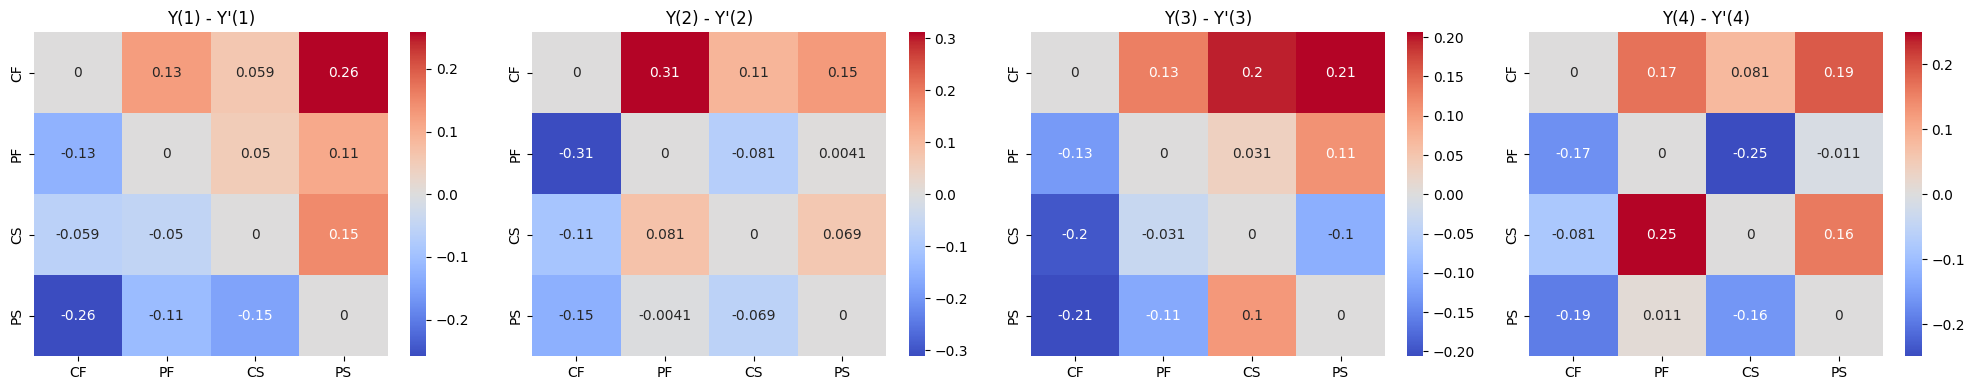

In [31]:
plot_antisymmetric_autocorr(
    returns_list=[R1, R2, R5, R6],
    column_names=["CentralFast", "PeripheralFast",
                  "CentralSlow", "PeripheralSlow"],
    labels=["CF", "PF", "CS", "PS"],
    annot=True
)

#### Autocorrelação

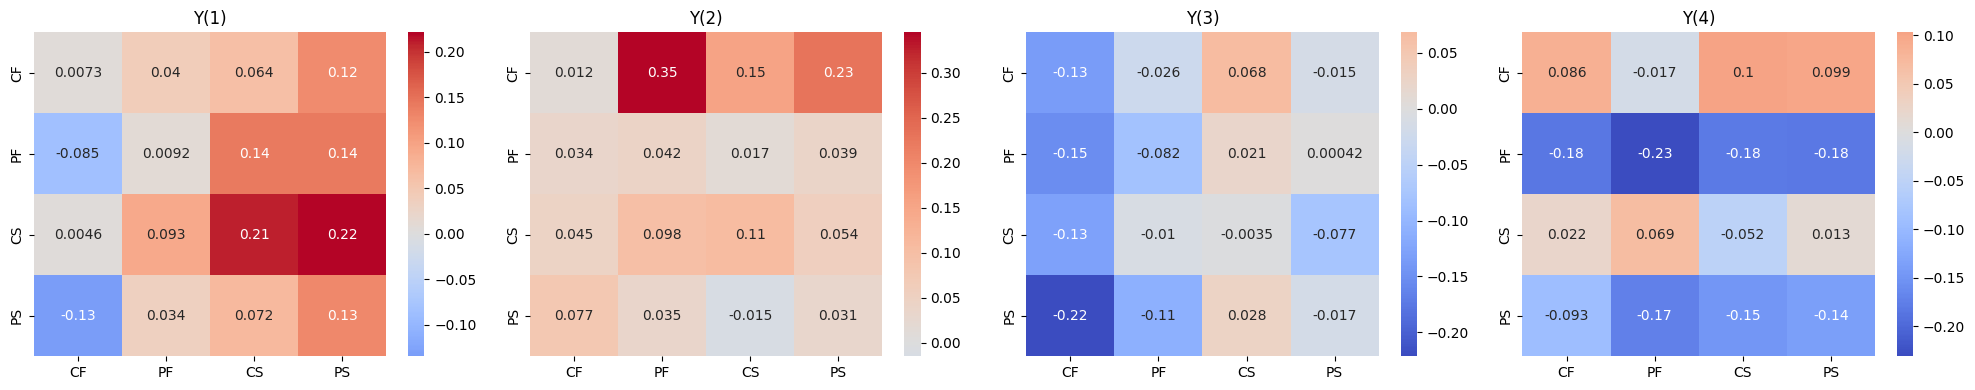

In [34]:
plot_antisymmetric_autocorr(
    returns_list=[R1, R2, R5, R6],
    column_names=["CentralFast", "PeripheralFast",
                  "CentralSlow", "PeripheralSlow"],
    labels=["CF", "PF", "CS", "PS"],
    annot=True,
    diff=False
)

### Fast - Medium

#### Diferença

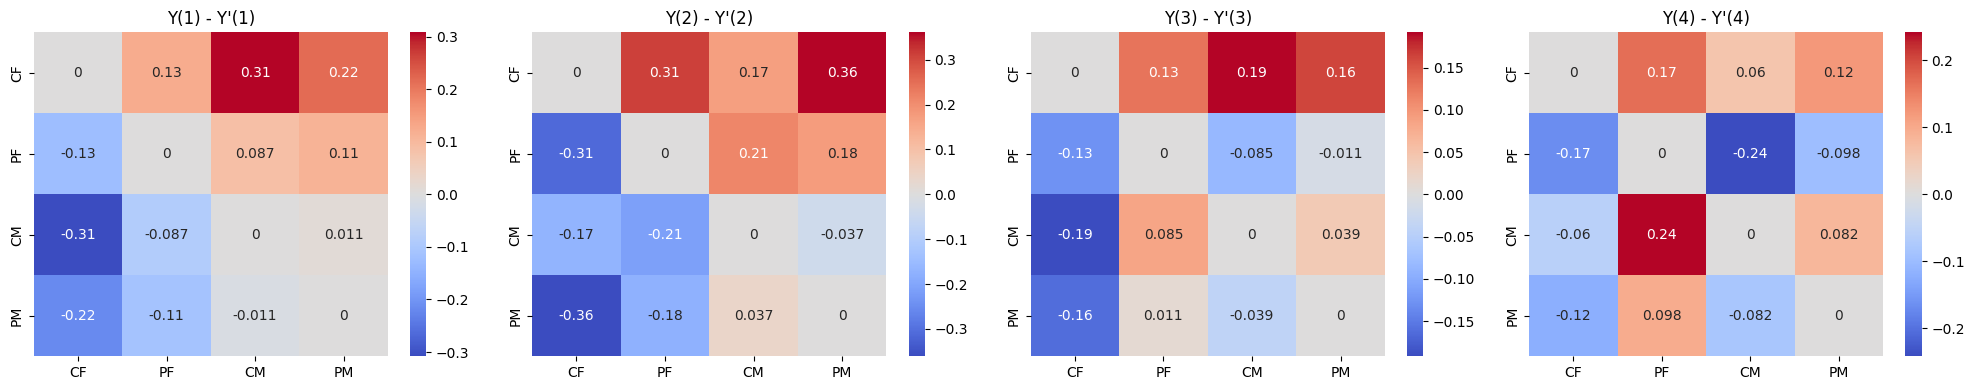

In [ ]:
plot_antisymmetric_autocorr(
    returns_list=[R1, R2, R3, R4],
    column_names=["CentralFast", "PeripheralFast",
                  "CentralMedium", "PeripheralMedium"],
    labels=["CF", "PF", "CM", "PM"],
    annot=True
)

#### Autocorrelação

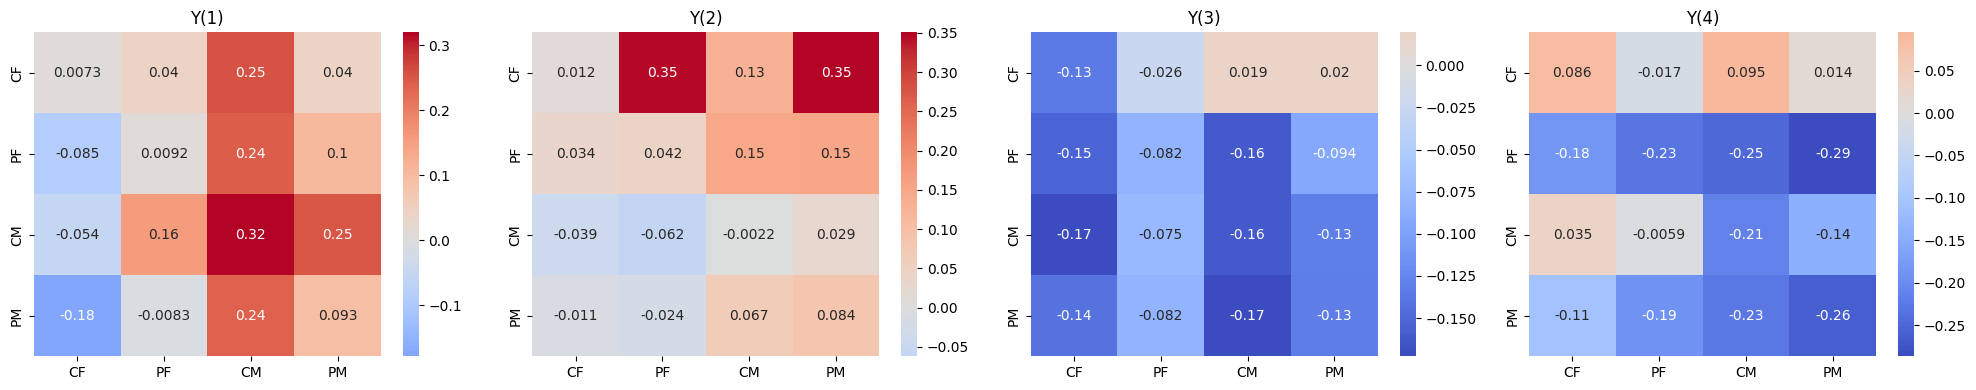

In [35]:
plot_antisymmetric_autocorr(
    returns_list=[R1, R2, R3, R4],
    column_names=["CentralFast", "PeripheralFast",
                  "CentralMedium", "PeripheralMedium"],
    labels=["CF", "PF", "CM", "PM"],
    annot=True,
    diff=False
)

### Medium - Slow

#### Diferença

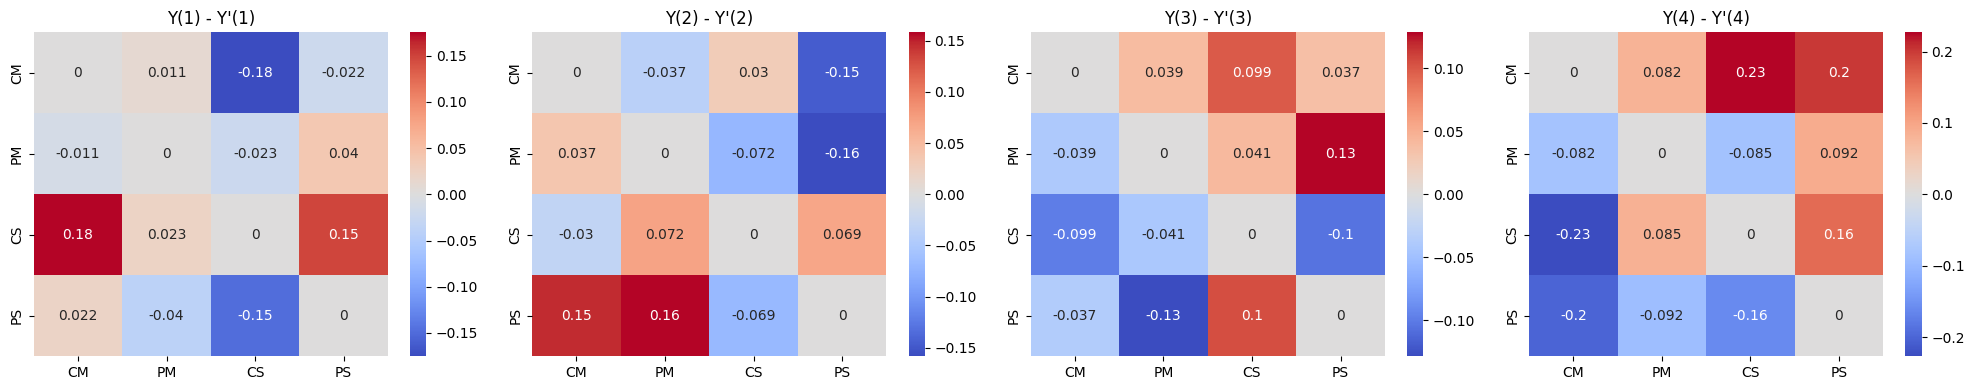

In [21]:
plot_antisymmetric_autocorr(
    returns_list=[R3, R4, R5, R6],
    column_names=["CentralMedium", "PeripheralMedium",
                  "CentralSlow", "PeripheralSlow"],
    labels=["CM", "PM", "CS", "PS"],
    annot=True
)

#### Autocorrelação

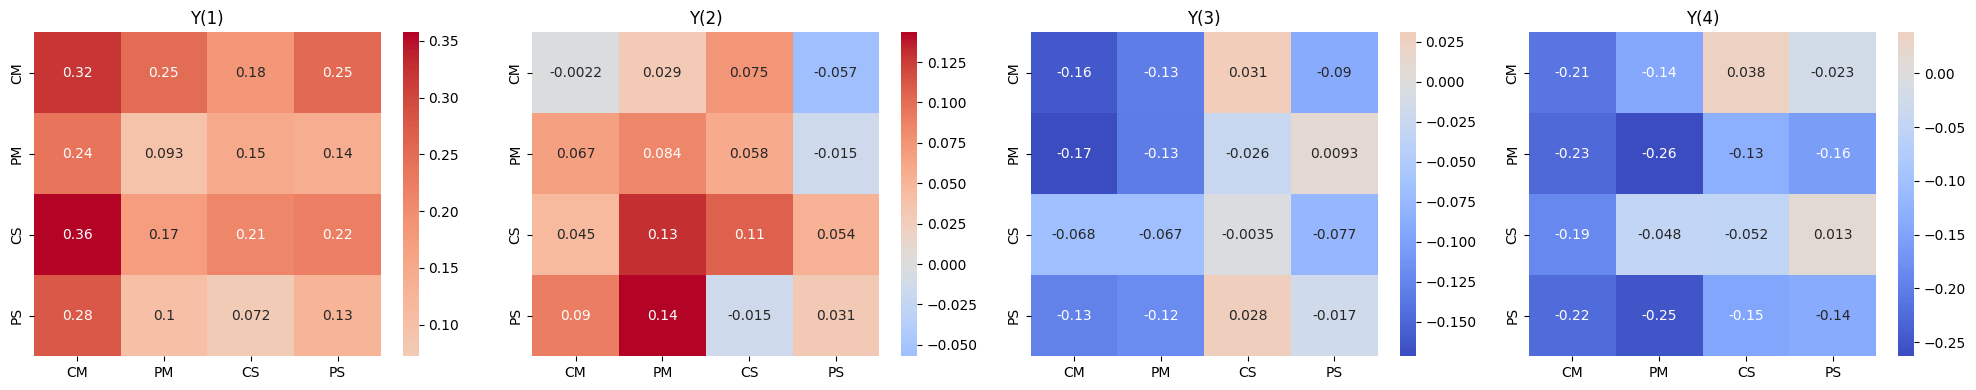

In [36]:
plot_antisymmetric_autocorr(
    returns_list=[R3, R4, R5, R6],
    column_names=["CentralMedium", "PeripheralMedium",
                  "CentralSlow", "PeripheralSlow"],
    labels=["CM", "PM", "CS", "PS"],
    annot=True,
    diff=False
)

### Lead-lag considerando Market Cap

In [22]:
df_mcap = pd.read_parquet("../../data/05_metrics/graph_metrics_df.parquet")
df_mcap["mcap_bin"] = (
    df_mcap.groupby("year_month_dt")["Market Cap"]
      .transform(lambda x: pd.qcut(
          x, q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"]
      ))
)

df_agg = df.merge(right=df_mcap[(df_mcap["year_month"]=="2019_12")
        & (df_mcap["speed"]=="Fast")][["node", "mcap_bin"]],
         how="inner",
         on=["node"])

In [23]:
# retornos semanais dos portfólios
R1 = returns_prev[list(df_agg[df_agg["mcap_bin"]=="Small"]["node"])].mean(axis=1)
R2 = returns_prev[list(df_agg[df_agg["mcap_bin"]=="Mid-Small"]["node"])].mean(axis=1)
R3 = returns_prev[list(df_agg[df_agg["mcap_bin"]=="Mid-Large"]["node"])].mean(axis=1)
R4 = returns_prev[list(df_agg[df_agg["mcap_bin"]=="Large"]["node"])].mean(axis=1)

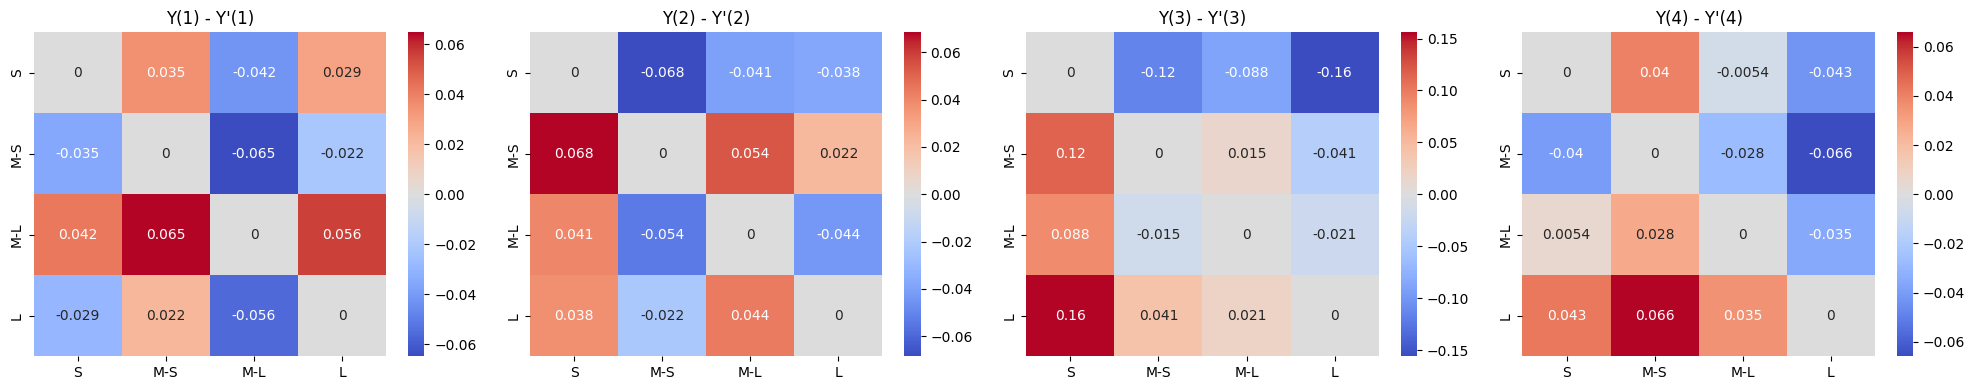

In [26]:
plot_antisymmetric_autocorr(
    returns_list=[R1, R2, R3, R4],
    column_names=["Small", "Mid-Small",
                  "Mid-Large", "Large"],
    labels=["S", "M-S", "M-L", "L"],
    annot=True
)

## Análise de risco -> em desenvolvimento

In [17]:
import yfinance as yf

sp500 = yf.download(tickers="^GSPC", start="2019-01-01", end="2019-12-31")["Close"].pct_change()[1:]
sp500_dr = sp500.mean(axis=1)

[*********************100%***********************]  1 of 1 completed


In [25]:
import statsmodels.api as sm

cols = ["CF", "PF", "CM", "PM", "CS", "PS"]
dr_list = [central_fast_daily_returns, peripheral_fast_daily_returns,
           central_medium_daily_returns, peripheral_medium_daily_returns,
           central_slow_daily_returns, peripheral_slow_daily_returns]

## FUNÇÕES AUXILIARES ##

def beta_ols(rp, rm):
    df = pd.concat([rp, rm], axis=1).dropna()
    y = df.iloc[:, 0]
    X = sm.add_constant(df.iloc[:, 1])
    model = sm.OLS(y, X).fit()
    return model.params[1], model.tvalues[1]

def sharpe_ratio(rp, rf=0.0):
    excess = rp - rf
    return (excess.mean() / excess.std()) * np.sqrt(252)


def sortino_ratio(rp, rf=0.0):
    excess = rp - rf
    downside = excess[excess < 0]
    downside_std = downside.std()
    return (excess.mean() / downside_std) * np.sqrt(252)


def var_historical(rp, alpha=0.95):
    return np.percentile(rp, (1 - alpha) * 100)


def max_drawdown(rp):
    cum = (1 + rp).cumprod()
    peak = cum.cummax()
    drawdown = (cum - peak) / peak
    return drawdown.min()

## CALCULANDO MÉTRICAS DE RISCO ##

risk_df = pd.DataFrame(columns=cols)

mean_return = []
volatility = []
beta = []
sharpe = []
sortino = []
var_95 = []
max_dd = []

for i in range(len(cols)):
    rp = dr_list[i]

    mean_return.append(rp.mean())
    volatility.append(rp.std() * np.sqrt(252))
    beta.append(beta_ols(rp, sp500_dr)[0])
    sharpe.append(sharpe_ratio(rp))
    sortino.append(sortino_ratio(rp))
    var_95.append(var_historical(rp, alpha=0.95))
    max_dd.append(max_drawdown(rp))

risk_df.loc["mean_return"] = mean_return
risk_df.loc["volatility"] = volatility
risk_df.loc["beta"] = beta
risk_df.loc["sharpe"] = sharpe
risk_df.loc["sortino"] = sortino
risk_df.loc["VaR_95"] = var_95
risk_df.loc["max_drawdown"] = max_dd
risk_df

,CF,PF,CM,PM,CS,PS
mean_return,0.001717,0.001098,0.001468,0.000856,0.001103,0.001168
volatility,0.212681,0.117088,0.210763,0.096314,0.140661,0.130506
beta,0.899225,0.861435,0.924987,0.699595,0.963392,0.855662
sharpe,2.033894,2.363952,1.755075,2.238980,1.975699,2.255297
sortino,3.984378,3.149428,3.324883,2.863044,2.717370,3.169991
VaR_95,-0.018446,-0.011711,-0.017336,-0.009123,-0.013985,-0.011891
max_drawdown,-0.112750,-0.063495,-0.152716,-0.055050,-0.098821,-0.068232


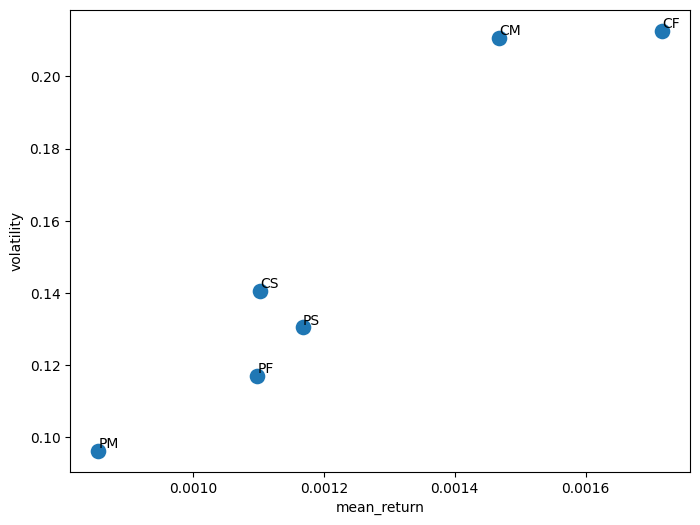

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=risk_df.T,
    x="mean_return",
    y="volatility",
    ax=ax,
    s=150
)

# adicionar rótulos
for label, row in risk_df.T.iterrows():
    ax.text(
        row["mean_return"],
        row["volatility"],
        label,
        fontsize=10,
        ha="left",
        va="bottom"
    )

plt.show()